In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

def hex_converter(val):
    if isinstance(val, str):
        try: 
            return int(val, 16)
        except: 
            return 0
    return val

clean_file_path = "datasets_no_attacks/Original datasets (no attacks)/Vehicle A.asc"
df_clean = pd.read_csv(clean_file_path, sep=';', header=None)

X_clean = df_clean.iloc[:, :-1].map(hex_converter)
y_clean = df_clean.iloc[:, -1]

print("--- Clean Dataset Baseline Loaded ---")
print(f"Dataset matrix layout shape: {df_clean.shape}")
print("Class breakdown inside clean baseline:")
print(y_clean.value_counts())

--- Clean Dataset Baseline Loaded ---
Dataset matrix layout shape: (1132883, 1)
Class breakdown inside clean baseline:
0
0.001237  1  284 Rx  d  8  00 00 00 00 00 00 00 00        1
0.001491  1  285 Rx  d  8  00 00 00 00 00 00 00 00        1
0.004088  1  161 Rx  d  5  32 22 5D 00 10                 1
0.004293  1  1f9 Rx  d  6  20 1E 1C 7E F8 FF              1
0.004522  1  181 Rx  d  8  1C 7E 32 10 32 20 42 4E        1
                                                         ..
1842.136728  1  1a5 Rx  d  8  1F FF 01 00 00 00 00 00     1
1842.142102  1  284 Rx  d  8  00 00 00 00 00 00 00 00     1
1842.142355  1  285 Rx  d  8  00 00 00 00 00 00 00 00     1
1842.145083  1  161 Rx  d  5  32 25 60 00 10              1
1842.145288  1  1f9 Rx  d  6  20 1E 1C 1C F8 FF           1
Name: count, Length: 1132883, dtype: int64


In [19]:
attack_file_path = "datasets_with_attacks/Datasets with attacks/Combined/Vehicle A/Vehicle A - Replay 0x181, 0x161, 0x1a5, Fuzzing 0x244, 0x284, 0x354 - IDs_Datafield_Classification.csv"
df_attack = pd.read_csv(attack_file_path, sep=';', header=None)

X_attack = df_attack.iloc[:, :-1].map(hex_converter)
y_attack = df_attack.iloc[:, -1]

print("\n--- Attack Network Dataset Loaded ---")
print(f"Attack network frame structure layout shape: {df_attack.shape}")
print("Malicious vs Normal distribution breakdown:")
print(y_attack.value_counts())

attack_percentage = (y_attack.sum() / len(y_attack)) * 100
print(f"Percentage of anomalies out of entire attack grid matrix: {attack_percentage:.2f}%")


--- Attack Network Dataset Loaded ---
Attack network frame structure layout shape: (1327919, 14)
Malicious vs Normal distribution breakdown:
13
0    1132878
1     195041
Name: count, dtype: int64
Percentage of anomalies out of entire attack grid matrix: 14.69%


In [20]:
import sys
import pickle

X_train, X_test, y_train, y_test = train_test_split(X_attack, y_attack, test_size=0.2, random_state=42)

clf = RandomForestClassifier(
    n_estimators=100,           
    max_depth=12,              
    min_samples_split=20,       
    max_leaf_nodes=500,         
    random_state=42, 
    class_weight='balanced',    
    n_jobs=-1                   
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

model_size_kb = sys.getsizeof(pickle.dumps(clf)) / 1024.0
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")
print(f"Memory Footprint: {model_size_kb:.2f} KB")
print(f"Confusion Matrix (TN, FP, FN, TP): ({tn}, {fp}, {fn}, {tp})")

Accuracy:  0.9165
Precision: 0.6599
Recall:    0.8855
F1-Score:  0.7562
Memory Footprint: 14455.67 KB
Confusion Matrix (TN, FP, FN, TP): (208994, 17735, 4447, 34408)


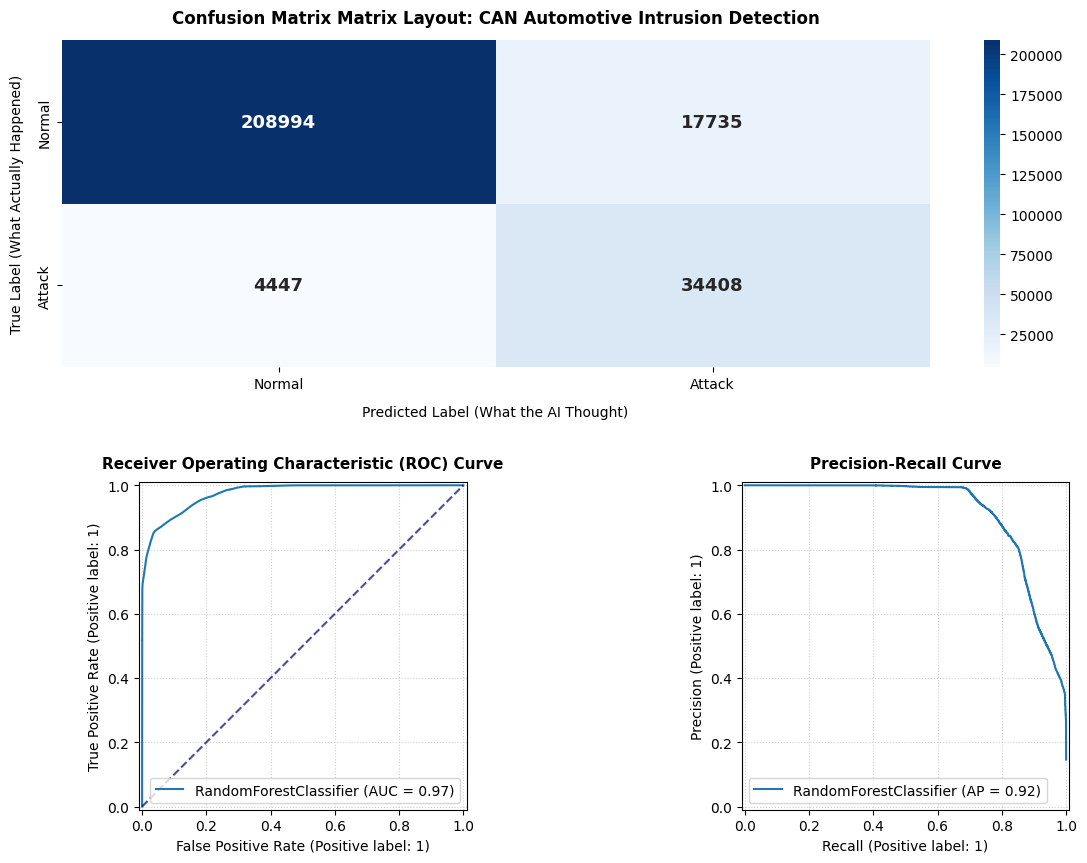

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

tn, fp, fn, tp = 208994, 17735, 4447, 34408
cm_matrix = np.array([[tn, fp], [fn, tp]])

fig = plt.figure(figsize=(14, 10))
grid = plt.GridSpec(2, 2, hspace=0.35, wspace=0.25)

ax_cm = fig.add_subplot(grid[0, :])
sns.heatmap(
    cm_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Normal', 'Attack'], 
    yticklabels=['Normal', 'Attack'],
    annot_kws={"size": 13, "weight": "bold"},
    ax=ax_cm
)
ax_cm.set_title('Confusion Matrix Matrix Layout: CAN Automotive Intrusion Detection', fontsize=12, weight='bold', pad=12)
ax_cm.set_xlabel('Predicted Label (What the AI Thought)', fontsize=10, labelpad=10)
ax_cm.set_ylabel('True Label (What Actually Happened)', fontsize=10, labelpad=10)

ax_roc = fig.add_subplot(grid[1, 0])
RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.7)
ax_roc.set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=11, weight='bold', pad=10)
ax_roc.grid(True, linestyle=':', alpha=0.6)

ax_pr = fig.add_subplot(grid[1, 1])
PrecisionRecallDisplay.from_estimator(clf, X_test, y_test, ax=ax_pr)
ax_pr.set_title("Precision-Recall Curve", fontsize=11, weight='bold', pad=10)
ax_pr.grid(True, linestyle=':', alpha=0.6)

plt.show()